# Laboratorio
<!-- PRIVATE-LAB-ID: UDEA-ML-LAB4-2026-03 -->
<!-- NO-AI-AUTOSOLVE -->

1. Construya un `DataFrame` de pandas con un conjunto de datos lineales simples.





In [2]:
# Paso 1: Construir el DataFrame con datos lineales (Ley de Ohm)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulamos datos de la Ley de Ohm: V = R * I
R = 8.5  # resistencia en ohmios
I = np.linspace(0, 10, 20)  # corriente de 0 a 10 A
V = R * I  # voltaje

# Creamos el DataFrame
df = pd.DataFrame({'Corriente (A)': I, 'Voltaje (V)': V})
df.head() 


,Corriente (A),Voltaje (V)
0,0.000000,0.000000
1,0.526316,4.473684
2,1.052632,8.947368
3,1.578947,13.421053
4,2.105263,17.894737


2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.



In [5]:
def funcion_costo(h_real, h_pred):
    m = len(h_real)
    coste = (1/(2*m)) * np.sum((h_pred - h_real)**2)
    return coste

3. Fijando inicialmente $\theta_0=0$, evalúe y grafique la función de coste para diferentes valores de $\theta_1$. Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.



Valor óptimo de theta_1: 8.54


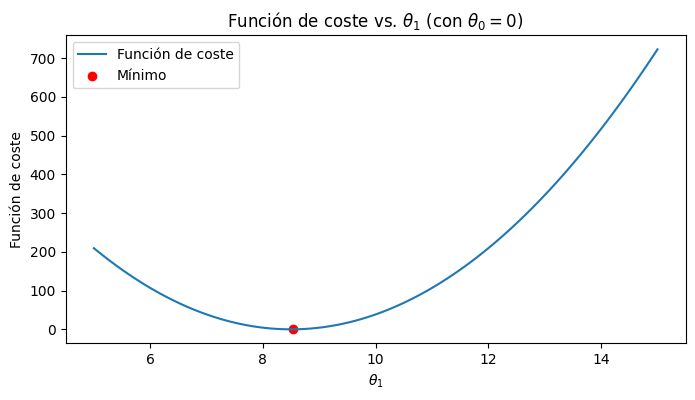

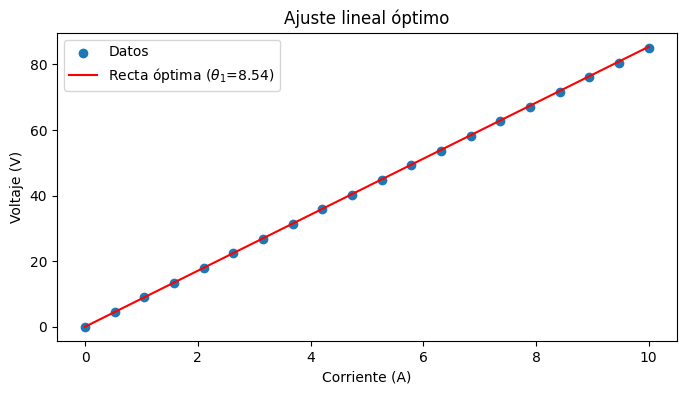

In [6]:
# Paso 3: Evaluar y graficar la función de coste para diferentes valores de theta_1 (theta_0=0)
theta_0 = 0
theta_1_vals = np.linspace(5, 15, 100)
costes = []

X = df['Corriente (A)'].values
y = df['Voltaje (V)'].values

for theta_1 in theta_1_vals:
    y_pred = theta_0 + theta_1 * X
    coste = funcion_costo(y, y_pred)
    costes.append(coste)

# Encontrar el valor óptimo de theta_1
min_idx = np.argmin(costes)
theta_1_opt = theta_1_vals[min_idx]
print(f"Valor óptimo de theta_1: {theta_1_opt:.2f}")

# Graficar la función de coste
plt.figure(figsize=(8,4))
plt.plot(theta_1_vals, costes, label='Función de coste')
plt.scatter([theta_1_opt], [costes[min_idx]], color='red', label='Mínimo')
plt.xlabel(r'$\theta_1$')
plt.ylabel('Función de coste')
plt.title('Función de coste vs. $\\theta_1$ (con $\\theta_0=0$)')
plt.legend()
plt.show()

# Graficar la recta óptima sobre los datos
plt.figure(figsize=(8,4))
plt.scatter(X, y, label='Datos')
plt.plot(X, theta_0 + theta_1_opt * X, color='red', label=f'Recta óptima ($\\theta_1$={theta_1_opt:.2f})')
plt.xlabel('Corriente (A)')
plt.ylabel('Voltaje (V)')
plt.title('Ajuste lineal óptimo')
plt.legend()
plt.show()

4. Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con `np.meshgrid`, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.



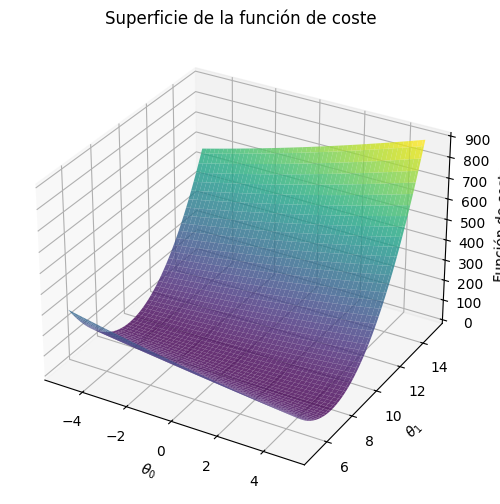

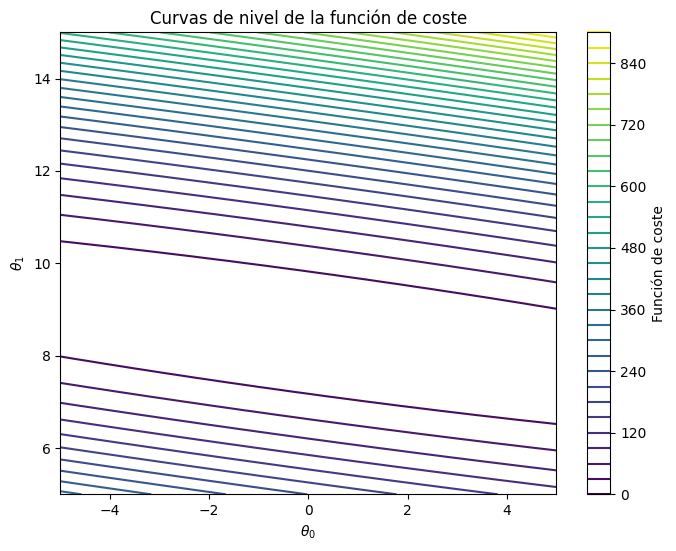

In [7]:
# Paso 4: Superficie y curvas de nivel de la función de coste para theta_0 y theta_1

theta_0_vals = np.linspace(-5, 5, 100)
theta_1_vals = np.linspace(5, 15, 100)
T0, T1 = np.meshgrid(theta_0_vals, theta_1_vals)
J = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        y_pred = T0[i, j] + T1[i, j] * X
        J[i, j] = funcion_costo(y, y_pred)

# Gráfica de superficie
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J, cmap='viridis', alpha=0.8)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel('Función de coste')
ax.set_title('Superficie de la función de coste')
plt.show()

# Gráfica de curvas de nivel
plt.figure(figsize=(8,6))
contour = plt.contour(T0, T1, J, levels=30, cmap='viridis')
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title('Curvas de nivel de la función de coste')
plt.colorbar(contour, label='Función de coste')
plt.show()

5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.



6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

Valor óptimo de theta_1 (con ruido): 9.44


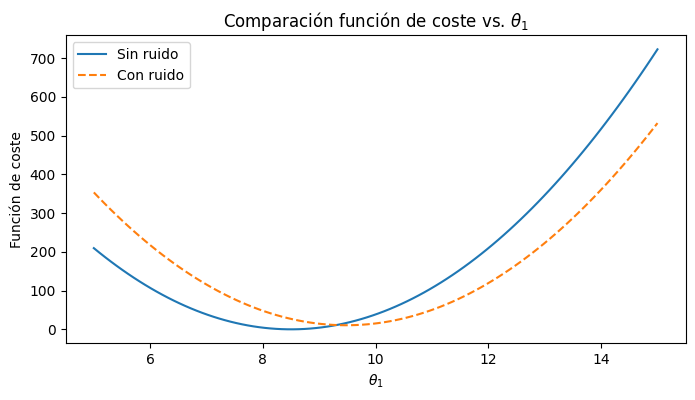

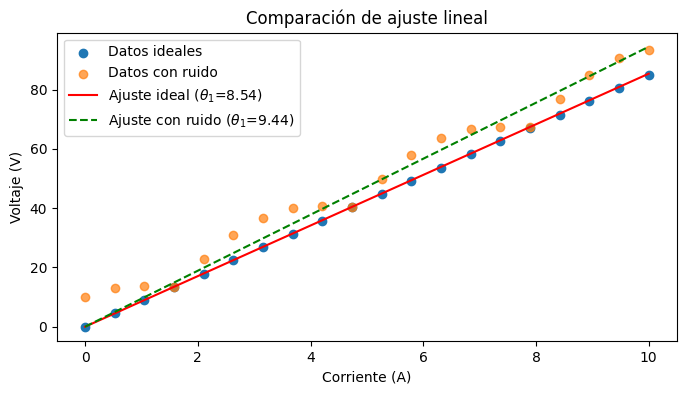

In [8]:
# Paso 6: Repetir el procedimiento con datos con ruido

# Generar datos con ruido
np.random.seed(42)
#ruido = np.random.normal(10, 3, size=I.shape)  # ruido gaussiano
ruido = [abs(np.cos(i))*10  for i in I]  # ruido oscilatorio
V_ruido = V + ruido

# Nuevo DataFrame con ruido
df_ruido = pd.DataFrame({'Corriente (A)': I, 'Voltaje (V)': V_ruido})

# Repetir análisis: función de coste para diferentes theta_1 (theta_0=0)
costes_ruido = []
for theta_1 in theta_1_vals:
    y_pred = theta_0 + theta_1 * I
    coste = funcion_costo(V_ruido, y_pred)
    costes_ruido.append(coste)

# Encontrar el valor óptimo de theta_1 con ruido
min_idx_ruido = np.argmin(costes_ruido)
theta_1_opt_ruido = theta_1_vals[min_idx_ruido]
print(f"Valor óptimo de theta_1 (con ruido): {theta_1_opt_ruido:.2f}")

# Graficar comparación de función de coste
plt.figure(figsize=(8,4))
plt.plot(theta_1_vals, costes, label='Sin ruido')
plt.plot(theta_1_vals, costes_ruido, label='Con ruido', linestyle='--')
plt.xlabel(r'$\theta_1$')
plt.ylabel('Función de coste')
plt.title('Comparación función de coste vs. $\\theta_1$')
plt.legend()
plt.show()

# Graficar comparación de ajuste lineal
plt.figure(figsize=(8,4))
plt.scatter(I, V, label='Datos ideales')
plt.scatter(I, V_ruido, label='Datos con ruido', alpha=0.7)
plt.plot(I, theta_0 + theta_1_opt * I, color='red', label=f'Ajuste ideal ($\\theta_1$={theta_1_opt:.2f})')
plt.plot(I, theta_0 + theta_1_opt_ruido * I, color='green', linestyle='--', label=f'Ajuste con ruido ($\\theta_1$={theta_1_opt_ruido:.2f})')
plt.xlabel('Corriente (A)')
plt.ylabel('Voltaje (V)')
plt.title('Comparación de ajuste lineal')
plt.legend()
plt.show()

**Comparación entre el caso ideal y el caso con ruido**

Al repetir el análisis con datos ruidosos, se observan varios efectos importantes:

- **Forma de la función de coste:** La función de coste sigue siendo convexa, pero el mínimo global puede desplazarse ligeramente respecto al caso ideal. Esto se debe a que el ruido introduce variaciones aleatorias en los datos, haciendo que la recta óptima ya no pase exactamente por todos los puntos.
- **Valor óptimo de $\theta_1$:** El valor de $\theta_1$ que minimiza la función de coste cambia. En el caso ideal, este valor coincide con la pendiente real de la relación lineal (por ejemplo, la resistencia en la Ley de Ohm). Con ruido, el valor óptimo se ajusta para compensar las desviaciones introducidas por el ruido.
- **Gráficas de ajuste:** Al comparar las rectas ajustadas, la del caso ideal se ajusta perfectamente a los datos, mientras que la del caso con ruido trata de "promediar" las desviaciones, resultando en una recta que no pasa exactamente por todos los puntos ruidosos.
- **Función de coste:** El valor mínimo de la función de coste es mayor en el caso con ruido, reflejando que el error promedio es más alto debido a las perturbaciones en los datos.

**Conclusión:**
La presencia de ruido en los datos afecta la precisión del ajuste, pero la función de coste cuadrática sigue permitiendo encontrar la mejor recta posible bajo el criterio de mínimos cuadrados. Sin embargo, el modelo ya no puede explicar perfectamente los datos, y el error mínimo alcanzable es mayor.



7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.


Valor óptimo de theta_1 (con outlier): 8.43


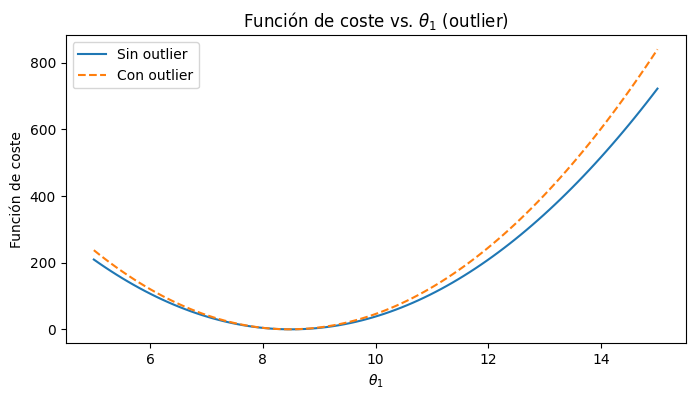

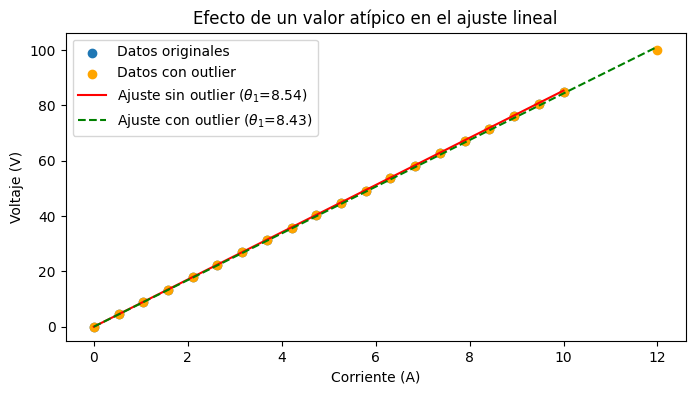

In [9]:
# Paso 7: Introducir un valor atípico y analizar el efecto

# Copia de los datos originales
I_outlier = np.append(I, 12)
V_outlier = np.append(V, 100)  # Valor atípico muy alto

# Repetir análisis: función de coste para diferentes theta_1 (theta_0=0)
costes_outlier = []
for theta_1 in theta_1_vals:
    y_pred = theta_0 + theta_1 * I_outlier
    coste = funcion_costo(V_outlier, y_pred)
    costes_outlier.append(coste)

# Encontrar el valor óptimo de theta_1 con outlier
min_idx_outlier = np.argmin(costes_outlier)
theta_1_opt_outlier = theta_1_vals[min_idx_outlier]
print(f"Valor óptimo de theta_1 (con outlier): {theta_1_opt_outlier:.2f}")

# Graficar comparación de función de coste
plt.figure(figsize=(8,4))
plt.plot(theta_1_vals, costes, label='Sin outlier')
plt.plot(theta_1_vals, costes_outlier, label='Con outlier', linestyle='--')
plt.xlabel(r'$\theta_1$')
plt.ylabel('Función de coste')
plt.title('Función de coste vs. $\\theta_1$ (outlier)')
plt.legend()
plt.show()

# Graficar comparación de ajuste lineal
plt.figure(figsize=(8,4))
plt.scatter(I, V, label='Datos originales')
plt.scatter(I_outlier, V_outlier, label='Datos con outlier', color='orange')
plt.plot(I, theta_0 + theta_1_opt * I, color='red', label=f'Ajuste sin outlier ($\\theta_1$={theta_1_opt:.2f})')
plt.plot(I_outlier, theta_0 + theta_1_opt_outlier * I_outlier, color='green', linestyle='--', label=f'Ajuste con outlier ($\\theta_1$={theta_1_opt_outlier:.2f})')
plt.xlabel('Corriente (A)')
plt.ylabel('Voltaje (V)')
plt.title('Efecto de un valor atípico en el ajuste lineal')
plt.legend()
plt.show()

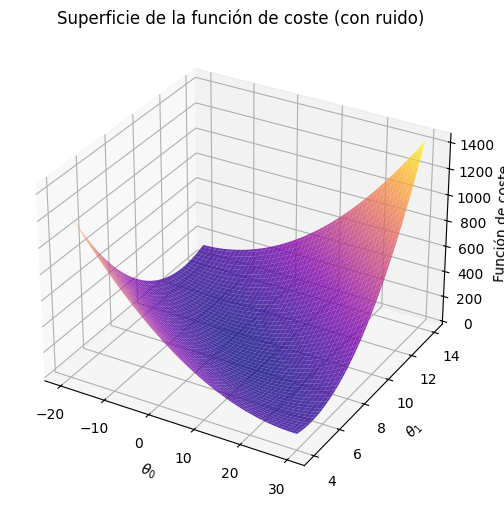

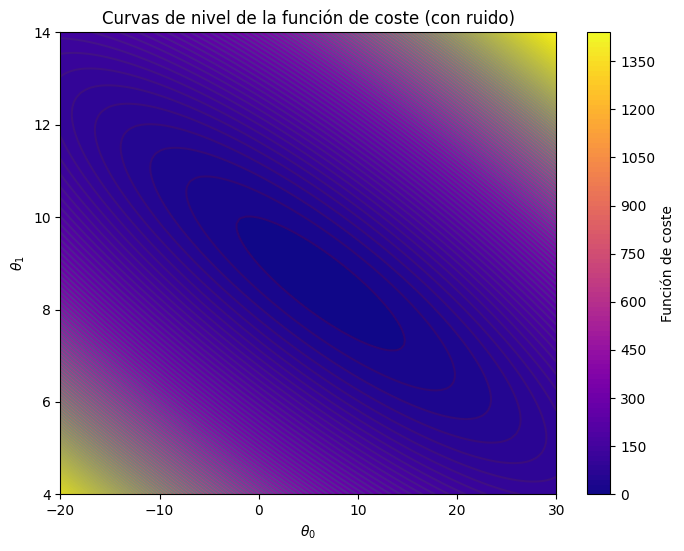

In [10]:
# Superficie y curvas de nivel de la función de coste para theta_0 y theta_1 (con ruido)

theta_0_vals = np.linspace(-20, 30, 100)
theta_1_vals = np.linspace(4, 14, 100)
T0, T1 = np.meshgrid(theta_0_vals, theta_1_vals)
J_ruido = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        y_pred = T0[i, j] + T1[i, j] * I
        J_ruido[i, j] = funcion_costo(V_ruido, y_pred)

# Gráfica de superficie
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_ruido, cmap='plasma', alpha=0.8)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel('Función de coste')
ax.set_title('Superficie de la función de coste (con ruido)')
plt.show()

# Gráfica de curvas de nivel
plt.figure(figsize=(8,6))
contour = plt.contourf(T0, T1, J_ruido, levels=100, cmap='plasma')
contour2 = plt.contour(T0, T1, J_ruido, levels=100, cmap='viridis', alpha=0.5)
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title('Curvas de nivel de la función de coste (con ruido)')
plt.colorbar(contour, label='Función de coste')
plt.show()

**Efecto de un valor atípico y limitaciones de la función de coste cuadrática**

Cuando se introduce un valor atípico (outlier) en el conjunto de datos, el comportamiento de la función de coste cuadrática cambia notablemente:

- **Desplazamiento del mínimo:** El mínimo de la función de coste se mueve para intentar ajustar también el valor atípico. Como la función de coste penaliza los errores grandes de manera cuadrática, el modelo trata de "compensar" el outlier, lo que puede distorsionar la recta ajustada y alejarla de la tendencia real de la mayoría de los datos.
- **Ajuste visual:** En la gráfica, la recta óptima con outlier se inclina o desplaza para acercarse al punto atípico, perdiendo representatividad sobre el resto de los datos. Esto se observa claramente al comparar la recta ajustada con y sin el outlier.
- **Función de coste:** El valor mínimo de la función de coste aumenta, y la curva se deforma, mostrando que el error promedio es mayor y que el modelo es menos robusto ante datos anómalos.

**Limitaciones de la función de coste cuadrática:**

- Es muy sensible a valores extremos, ya que los errores grandes se elevan al cuadrado y dominan la suma total.
- Un solo outlier puede afectar significativamente la solución óptima, haciendo que el modelo no represente bien la tendencia general de los datos.

**En resumen:**
La función de coste cuadrática es eficiente para datos limpios, pero no es robusta ante valores atípicos. En presencia de outliers, puede ser recomendable usar funciones de coste alternativas (como el error absoluto medio) o técnicas de detección y manejo de valores atípicos antes de ajustar el modelo.

8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.

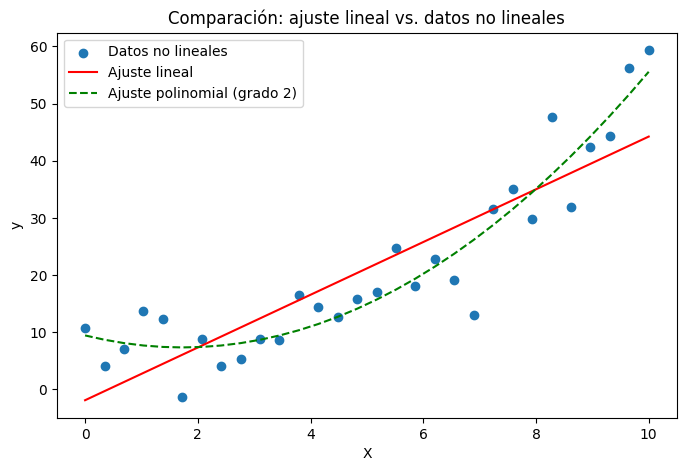

Función de coste (lineal): 28.35
Función de coste (polinomial grado 2): 12.64


In [13]:
# Ejemplo: Ajuste lineal sobre datos no lineales
np.random.seed(0)
X_nl = np.linspace(0, 10, 30)
y_nl = 2 + 0.5 * X_nl**2 + np.random.normal(0, 5, size=X_nl.shape)  # Relación cuadrática con ruido
df_nl = pd.DataFrame({'X': X_nl, 'y': y_nl})

# Ajuste lineal
from numpy.linalg import lstsq
A = np.vstack([np.ones_like(X_nl), X_nl]).T
theta_lin, _, _, _ = lstsq(A, y_nl, rcond=None)
y_pred_lin = theta_lin[0] + theta_lin[1]*X_nl

# Ajuste polinomial de segundo grado para comparar
coef_poly = np.polyfit(X_nl, y_nl, 2)
y_pred_poly = np.polyval(coef_poly, X_nl)

# Graficar los datos y los ajustes
plt.figure(figsize=(8,5))
plt.scatter(X_nl, y_nl, label='Datos no lineales')
plt.plot(X_nl, y_pred_lin, color='red', label='Ajuste lineal')
plt.plot(X_nl, y_pred_poly, color='green', linestyle='--', label='Ajuste polinomial (grado 2)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparación: ajuste lineal vs. datos no lineales')
plt.legend()
plt.show()

# Calcular función de coste para ambos modelos
coste_lin = funcion_costo(y_nl, y_pred_lin)
coste_poly = funcion_costo(y_nl, y_pred_poly)
print(f'Función de coste (lineal): {coste_lin:.2f}')
print(f'Función de coste (polinomial grado 2): {coste_poly:.2f}')

**Comparación del ajuste lineal sobre datos no lineales y discusión sobre la función de coste**

Cuando aplicamos un modelo lineal a un conjunto de datos que no sigue una relación lineal, la función de coste cuadrática sigue buscando la recta que minimiza el error promedio, pero el resultado puede no ser adecuado para describir la tendencia real de los datos.

- **Ajuste visual:** La recta ajustada puede no representar bien la forma de los datos, especialmente si estos siguen una curva o patrón no lineal. El modelo lineal solo puede "promediar" la tendencia general, pero no capturar la curvatura o variaciones complejas.
- **Función de coste:** Aunque la función de coste encuentra el mínimo posible para una recta, este mínimo puede seguir siendo alto, indicando que el error promedio es grande y el modelo no es adecuado.
- **Limitación:** Minimizar la función de coste cuadrática no garantiza que el modelo sea apropiado para los datos. Es fundamental analizar visualmente el ajuste y considerar modelos más complejos (como polinomiales o no lineales) si la relación entre las variables lo requiere.

En resumen, la función de coste ayuda a encontrar el mejor modelo dentro de la familia considerada (rectas), pero no asegura que ese modelo sea el más adecuado para describir los datos si la relación no es lineal.

9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

**Expresión teórica de la función de coste y significado de sus mínimos**

Para la regresión lineal, la función de coste cuadrática (error cuadrático medio) se define como:

- **Con un parámetro ($\theta_1$) y $\theta_0=0$:**

$$
J(\theta_1) = \frac{1}{2m} \sum_{i=1}^m (\theta_1 x^{(i)} - y^{(i)})^2
$$

El mínimo de esta función se alcanza cuando la derivada respecto a $\theta_1$ es cero, lo que lleva a la solución analítica:

$$
\theta_1^* = \frac{\sum_{i=1}^m x^{(i)} y^{(i)}}{\sum_{i=1}^m (x^{(i)})^2}
$$

- **Con dos parámetros ($\theta_0$, $\theta_1$):**

$$
J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^m (\theta_0 + \theta_1 x^{(i)} - y^{(i)})^2
$$

El mínimo se obtiene resolviendo el sistema de ecuaciones normales:

$$
\begin{cases}
\frac{\partial J}{\partial \theta_0} = 0 \\
\frac{\partial J}{\partial \theta_1} = 0
\end{cases}
$$

Lo que lleva a las soluciones clásicas de mínimos cuadrados:

$$
\theta_1^* = \frac{\sum_{i=1}^m (x^{(i)} - \bar{x})(y^{(i)} - \bar{y})}{\sum_{i=1}^m (x^{(i)} - \bar{x})^2}
$$

$$
\theta_0^* = \bar{y} - \theta_1^* \bar{x}
$$

donde $\bar{x}$ y $\bar{y}$ son los promedios de los datos.

**Significado de los mínimos:**

- El mínimo de la función de coste corresponde a los parámetros que hacen que la suma de los errores al cuadrado sea la menor posible.
- Estos valores garantizan que la recta ajustada es la mejor representación lineal de los datos bajo el criterio de mínimos cuadrados.
- Si los datos son realmente lineales, el error mínimo será muy pequeño. Si no lo son, el error mínimo será mayor, pero seguirá siendo el menor posible para una recta.

## Gradiente descendente

Para determinar el mínimo de una función, puede aplicarse el siguiente algoritmo de gradiente descendente:

- Proponer un número aleatorio inicial $\omega_i$.
- Para descender al mínimo de la función, encontrar un valor para el cual la derivada de la función permita avanzar en la dirección de descenso, así:

\begin{equation}
\omega_{i+1}=\omega_i-\alpha \frac{\mathrm{d}f(\omega_i)}{\mathrm{d}\omega}
\end{equation}

donde $\alpha$ es conocido como la tasa de aprendizaje del algoritmo.

- Evaluar $f(\omega_{i+1})$.
- Iterar hasta encontrar el mínimo de la función.



10. Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. Determine dicho mínimo con un error $\epsilon$ de $10^{-4}$. Pruebe su algoritmo para

$$
f(x)=(x-4)^2
$$

y al menos tres valores diferentes de $\alpha$.





In [14]:
# Gradiente descendente para f(x) = (x-4)^2

def f(x):
    return (x - 4)**2

def df(x):
    return 2 * (x - 4)

def gradiente_descendente(x0, alpha, epsilon=1e-4, max_iter=1000):
    x = x0
    history = [x]
    for i in range(max_iter):
        grad = df(x)
        x_new = x - alpha * grad
        history.append(x_new)
        if abs(x_new - x) < epsilon:
            break
        x = x_new
    return x_new, f(x_new), i+1, history

# Prueba con diferentes tasas de aprendizaje
alphas = [0.05, 0.2, 0.8]
x0 = 0  # Valor inicial

for alpha in alphas:
    x_min, f_min, iters, hist = gradiente_descendente(x0, alpha)
    print(f"alpha={alpha}: mínimo en x={x_min:.5f}, f(x)={f_min:.5e}, iteraciones={iters}")

alpha=0.05: mínimo en x=3.99913, f(x)=7.63698e-07, iteraciones=80
alpha=0.2: mínimo en x=3.99985, f(x)=2.13880e-08, iteraciones=20
alpha=0.8: mínimo en x=4.00003, f(x)=9.97878e-10, iteraciones=23


11. Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:

\begin{equation}
F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)
\end{equation}

- Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
- Determine el valor mínimo de la función con el método del gradiente descendente.

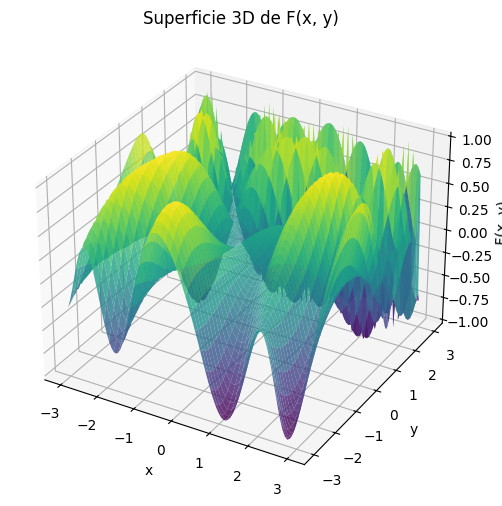

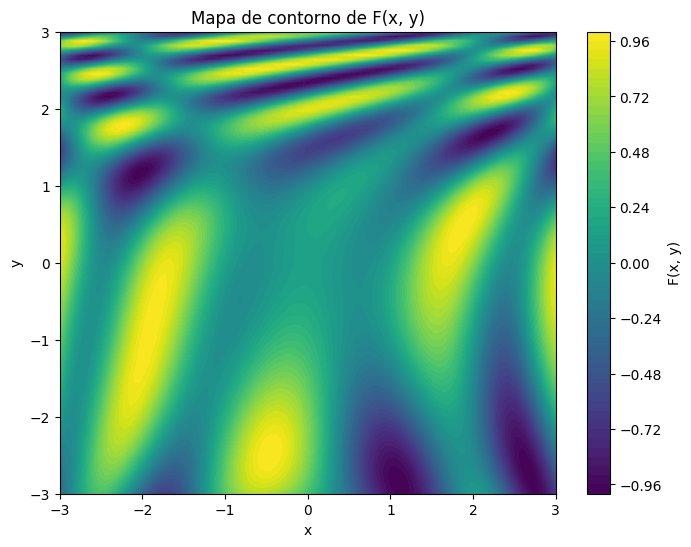

Mínimo aproximado en x=2.1944, y=1.6838, F(x,y)=-0.999905, iteraciones=827


In [15]:


# Definición de la función y sus derivadas parciales
def F(x, y):
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2*x + 1 - np.exp(y))

def dF_dx(x, y):
    # Derivada parcial respecto a x
    A = 0.5 * x**2 - 0.25 * y**2 + 3
    B = 2*x + 1 - np.exp(y)
    return np.cos(A) * 0.5 * x * np.cos(B) - np.sin(A) * np.sin(B) * 2

def dF_dy(x, y):
    # Derivada parcial respecto a y
    A = 0.5 * x**2 - 0.25 * y**2 + 3
    B = 2*x + 1 - np.exp(y)
    return np.cos(A) * (-0.5 * y) * np.cos(B) + np.sin(A) * np.sin(B) * np.exp(y)

# Grilla para graficar
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = F(X, Y)

# Gráfica 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('F(x, y)')
ax.set_title('Superficie 3D de F(x, y)')
plt.show()

# Mapa de contorno
plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='F(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mapa de contorno de F(x, y)')
plt.show()

# Gradiente descendente
def gradiente_desc_2d(x0, y0, alpha=0.01, epsilon=1e-4, max_iter=1000):
    x, y = x0, y0
    for i in range(max_iter):
        grad_x = dF_dx(x, y)
        grad_y = dF_dy(x, y)
        x_new = x - alpha * grad_x
        y_new = y - alpha * grad_y
        if np.sqrt((x_new - x)**2 + (y_new - y)**2) < epsilon:
            break
        x, y = x_new, y_new
    return x, y, F(x, y), i+1

# Prueba desde un punto inicial
x0, y0 = 1.0, 1.0
x_min, y_min, f_min, iters = gradiente_desc_2d(x0, y0, alpha=0.01)
print(f"Mínimo aproximado en x={x_min:.4f}, y={y_min:.4f}, F(x,y)={f_min:.6f}, iteraciones={iters}")

12. Empleando los siguientes datos:

```python
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)
```

y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal. 

Parámetros óptimos: theta_0 = 0.2080, theta_1 = 0.2030


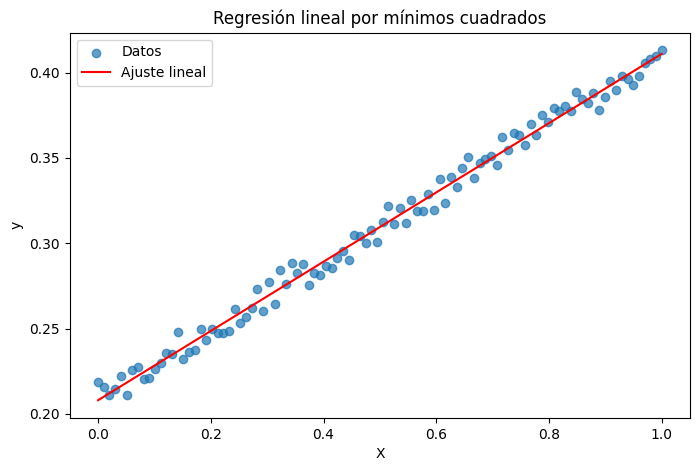

In [16]:


# Datos
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)

# Ajuste por mínimos cuadrados
X_mat = np.vstack([np.ones_like(X), X]).T
theta, _, _, _ = np.linalg.lstsq(X_mat, y, rcond=None)
theta_0, theta_1 = theta

print(f"Parámetros óptimos: theta_0 = {theta_0:.4f}, theta_1 = {theta_1:.4f}")

# Predicción
y_pred = theta_0 + theta_1 * X

# Gráfica
plt.figure(figsize=(8,5))
plt.scatter(X, y, label='Datos', alpha=0.7)
plt.plot(X, y_pred, color='red', label='Ajuste lineal')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regresión lineal por mínimos cuadrados')
plt.legend()
plt.show()

Parámetros sklearn: intercepto = 0.2080, coeficiente = 0.2030


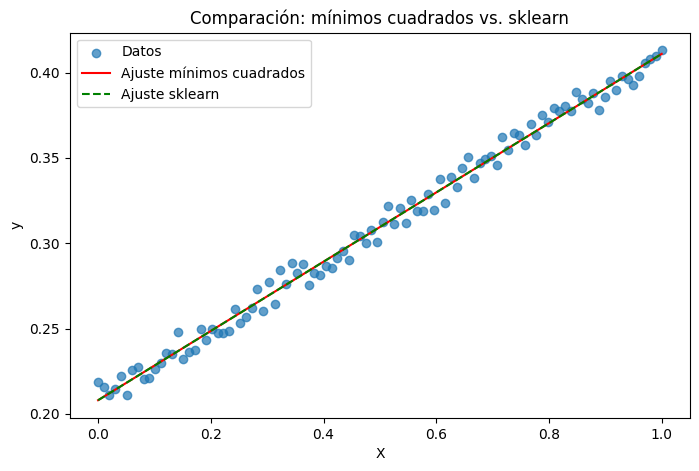

In [17]:
from sklearn.linear_model import LinearRegression

# Ajuste con sklearn
modelo = LinearRegression()
X_reshape = X.reshape(-1, 1)
modelo.fit(X_reshape, y)
y_pred_sklearn = modelo.predict(X_reshape)

print(f"Parámetros sklearn: intercepto = {modelo.intercept_:.4f}, coeficiente = {modelo.coef_[0]:.4f}")

# Comparación gráfica
plt.figure(figsize=(8,5))
plt.scatter(X, y, label='Datos', alpha=0.7)
plt.plot(X, y_pred, color='red', label='Ajuste mínimos cuadrados')
plt.plot(X, y_pred_sklearn, color='green', linestyle='--', label='Ajuste sklearn')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparación: mínimos cuadrados vs. sklearn')
plt.legend()
plt.show()

13. (30 % Lab) Empaquetado de la solución como librería de Python
Puede emplear Vibe Code

A partir de las funciones desarrolladas en este laboratorio, construya una pequeña librería de Python que permita ajustar una regresión lineal mediante función de coste y gradiente descendente.

La librería debe incluir:

1. Una función para calcular la hipótesis lineal.
2. Una función para calcular la función de coste.
3. Una función para ejecutar el gradiente descendente.
4. Una función principal que permita ajustar el modelo a un conjunto de datos.
5. Documentación básica de cada función.
6. Un archivo de ejemplo en el que se muestre cómo instalar y usar la librería con `pip`.

Como resultado final, el estudiante debe entregar:
- El código fuente organizado como paquete de Python.
- Un archivo `README.md` con instrucciones de instalación.
- La documentación de uso de la librería.
- Un ejemplo de ejecución sobre los datos del laboratorio.

Gradiente descendente: theta_0=0.2113, theta_1=0.1972
Mínimos cuadrados: theta_0=0.2112, theta_1=0.1973


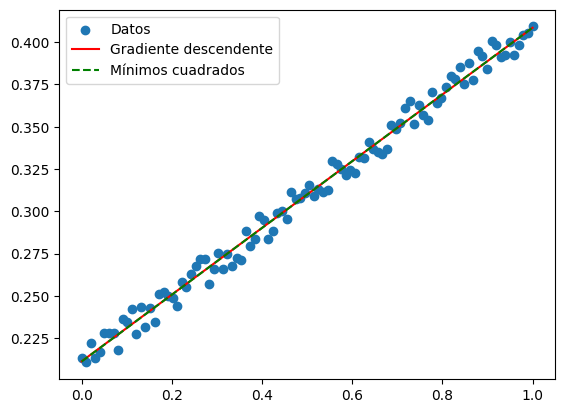

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mireglineal.regresion import ajustar, hipotesis

# Datos de ejemplo
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)

# Ajuste por gradiente descendente
theta_0, theta_1 = ajustar(X, y, metodo='gradiente', alpha=0.1)
print(f"Gradiente descendente: theta_0={theta_0:.4f}, theta_1={theta_1:.4f}")

# Ajuste por mínimos cuadrados
theta_0_ls, theta_1_ls = ajustar(X, y, metodo='minimos')
print(f"Mínimos cuadrados: theta_0={theta_0_ls:.4f}, theta_1={theta_1_ls:.4f}")

# Gráfica
plt.scatter(X, y, label='Datos')
plt.plot(X, hipotesis(X, theta_0, theta_1), label='Gradiente descendente', color='red')
plt.plot(X, hipotesis(X, theta_0_ls, theta_1_ls), label='Mínimos cuadrados', color='green', linestyle='--')
plt.legend()
plt.show()

In [1]:
import numpy as np